In [ ]:
# Mount Google Drive to save checkpoints
from google.colab import drive
drive.mount('/content/drive')

# Check GPU
import torch
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

# Create project folder in Drive
import os
os.makedirs('/content/drive/MyDrive/NewsImageCNN', exist_ok=True)
os.makedirs('/content/drive/MyDrive/NewsImageCNN/checkpoints', exist_ok=True)
print("Project folders created in Google Drive!")

Mounted at /content/drive
GPU Available: False
GPU Name: No GPU
Project folders created in Google Drive!


In [ ]:
# Upload your kaggle.json
from google.colab import files
files.upload()  # upload kaggle.json here

# Setup Kaggle
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.config/kaggle/')
os.system('chmod 600 /root/.config/kaggle/kaggle.json')

# Download Intel Image Classification dataset
os.system('kaggle datasets download -d puneet6060/intel-image-classification')

# Unzip
os.system('unzip -q intel-image-classification.zip -d /content/intel_data')
print("Dataset ready!")

# Check structure
for root, dirs, files_list in os.walk('/content/intel_data'):
    level = root.replace('/content/intel_data', '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')

Saving kaggle.json to kaggle.json
Dataset ready!
intel_data/
  seg_train/
    seg_train/
  seg_test/
    seg_test/
  seg_pred/
    seg_pred/


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time
import copy

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Class names
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder('/content/intel_data/seg_train/seg_train',
                                      transform=train_transforms)
val_dataset   = datasets.ImageFolder('/content/intel_data/seg_test/seg_test',
                                      transform=val_transforms)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

print(f"Training samples   : {len(train_dataset)}")
print(f"Validation samples : {len(val_dataset)}")
print(f"Classes            : {class_names}")

Using device: cuda
Training samples   : 14034
Validation samples : 3000
Classes            : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
# Load pretrained ResNet50
model = models.resnet50(pretrained=True)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for 6 classes
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 6)
)

model = model.to(device)
print("ResNet50 loaded and modified for 6 classes!")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


ResNet50 loaded and modified for 6 classes!
Trainable parameters: 526,086


In [ ]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# Training history
history = {'train_loss': [], 'val_loss': [],
           'train_acc': [],  'val_acc': []}

best_val_acc = 0.0
EPOCHS = 10
checkpoint_path = '/content/drive/MyDrive/NewsImageCNN/checkpoints/best_model.pth'

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            loader = train_loader
        else:
            model.eval()
            loader = val_loader

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss     += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        if phase == 'train':
            scheduler.step()

        epoch_loss = running_loss / len(loader.dataset)
        epoch_acc  = running_corrects.double() / len(loader.dataset)

        print(f"{phase.upper()} — Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc.item())
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc.item())

            # Save best model
            if epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                torch.save(model.state_dict(), checkpoint_path)
                print(f"  ✅ Best model saved! Val Acc: {best_val_acc:.4f}")

print("\nTraining Complete!")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")


Epoch 1/10
----------------------------------------
TRAIN — Loss: 0.5554  Acc: 0.7936
VAL — Loss: 0.3321  Acc: 0.8793
  ✅ Best model saved! Val Acc: 0.8793

Epoch 2/10
----------------------------------------
TRAIN — Loss: 0.4142  Acc: 0.8477
VAL — Loss: 0.3510  Acc: 0.8620

Epoch 3/10
----------------------------------------
TRAIN — Loss: 0.3902  Acc: 0.8575
VAL — Loss: 0.2876  Acc: 0.8913
  ✅ Best model saved! Val Acc: 0.8913

Epoch 4/10
----------------------------------------
TRAIN — Loss: 0.3763  Acc: 0.8601
VAL — Loss: 0.2874  Acc: 0.8873

Epoch 5/10
----------------------------------------
TRAIN — Loss: 0.3638  Acc: 0.8672
VAL — Loss: 0.2730  Acc: 0.8923
  ✅ Best model saved! Val Acc: 0.8923

Epoch 6/10
----------------------------------------
TRAIN — Loss: 0.3113  Acc: 0.8871
VAL — Loss: 0.2636  Acc: 0.8993
  ✅ Best model saved! Val Acc: 0.8993

Epoch 7/10
----------------------------------------
TRAIN — Loss: 0.2986  Acc: 0.8913
VAL — Loss: 0.2647  Acc: 0.9010
  ✅ Best model 

In [ ]:
# Load best model
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

   buildings       0.88      0.94      0.91       437
      forest       0.99      0.99      0.99       474
     glacier       0.89      0.81      0.84       553
    mountain       0.84      0.86      0.85       525
         sea       0.91      0.97      0.94       510
      street       0.94      0.90      0.92       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.90      3000



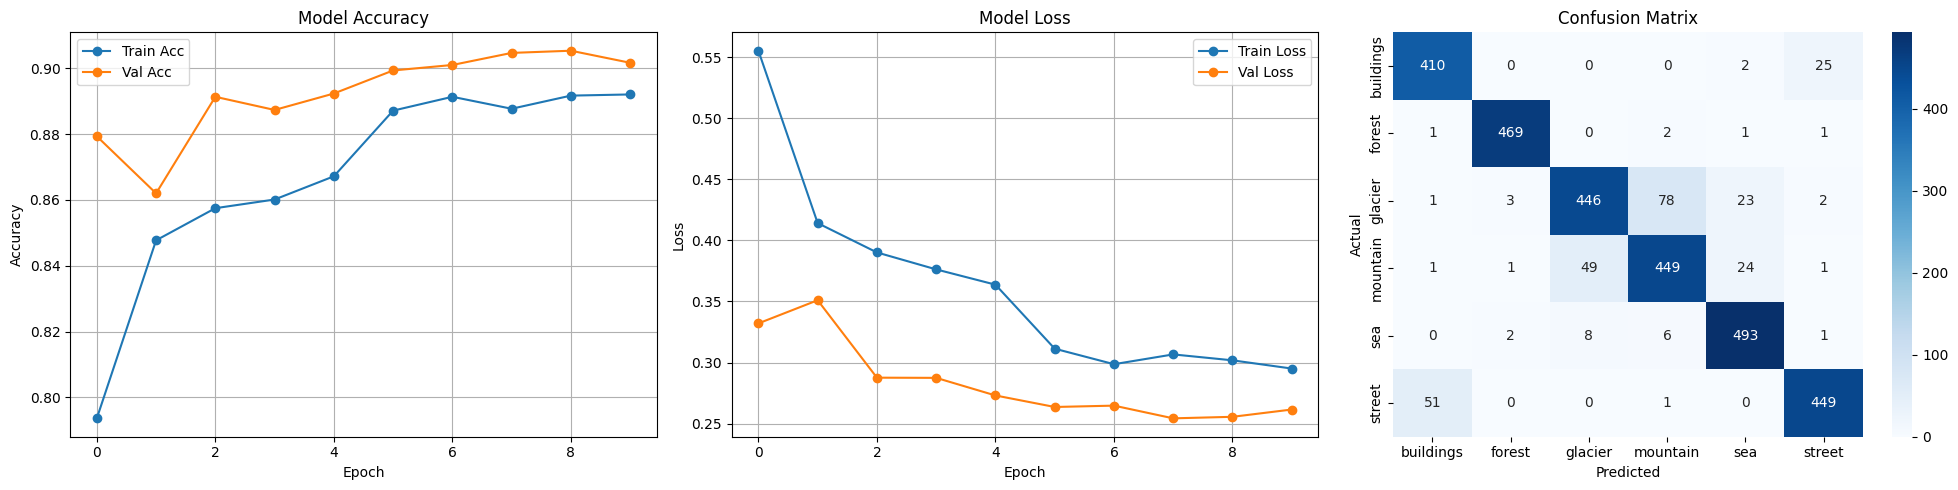

Results saved to Drive!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1 - Accuracy
axes[0].plot(history['train_acc'], label='Train Acc', marker='o')
axes[0].plot(history['val_acc'],   label='Val Acc',   marker='o')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot 2 - Loss
axes[1].plot(history['train_loss'], label='Train Loss', marker='o')
axes[1].plot(history['val_loss'],   label='Val Loss',   marker='o')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Plot 3 - Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names, ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NewsImageCNN/results.png', dpi=150)
plt.show()
print("Results saved to Drive!")

In [ ]:
!unrar x "/content/drive/MyDrive/NewsImageCNN/dataset/UCF101.rar"

Streaming output truncated to the last 5000 lines.
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c05.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c06.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c07.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c01.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c02.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c03.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c04.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c05.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c06.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c07.avi             62%  OK 
Extracting  UCF-101/PlayingGu

In [ ]:
import os

# Check where files got extracted
base_path = '/content/UCF-101'  # default unrar location

# If not found there, search
if not os.path.exists(base_path):
    for root, dirs, files in os.walk('/content'):
        for d in dirs:
            if 'UCF' in d or 'ucf' in d:
                print("Found at:", os.path.join(root, d))
        break

# Check structure
if os.path.exists(base_path):
    classes = os.listdir(base_path)
    print(f"Total classes found: {len(classes)}")
    print(f"\nFirst 10 classes: {classes[:10]}")

    # Count videos in first class
    sample_class = classes[0]
    videos = os.listdir(os.path.join(base_path, sample_class))
    print(f"\nSample class '{sample_class}' has {len(videos)} videos")
else:
    print("Path not found, run the search above")

Total classes found: 101

First 10 classes: ['IceDancing', 'Lunges', 'Skijet', 'HandstandWalking', 'ShavingBeard', 'SoccerJuggling', 'BlowDryHair', 'Bowling', 'Biking', 'PlayingFlute']

Sample class 'IceDancing' has 158 videos
